Mise en place de trading patterns

In [1]:
%load_ext autoreload
%autoreload 2
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pandas_ta as ta
import scipy
import sys
import seaborn as sns
import os
import copy
import datetime
import optuna
import itertools
from tqdm import tqdm
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import MinMaxScaler,OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from xgboost import XGBClassifier
from sklearn.metrics import confusion_matrix,f1_score,accuracy_score,r2_score,roc_auc_score
from sklearn.model_selection import cross_val_score
from sklearn.metrics import mean_absolute_percentage_error, mean_squared_error
sys.path.append(os.getcwd()) 
from optimi import merge_pattern_df

c:\Users\GONONDYA\AppData\Local\anaconda3\envs\Y1\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
def choose_path(candidates):
    import os
    for p in candidates:
        if os.path.exists(p):
            return p
    return candidates[-1]
path_returns = choose_path([r"C:\\GoogleDrive\\TP\\screen\\returns.pkl", r"\\\\groupe-ufg.com\\commun\\Prive\\GestionAM\\Ingenierie_Financiere\\PROD\\_EQUITY\\0_RETURNS\\returns.pkl"]) 
returns = pd.read_pickle(path_returns) 
liste_noire =r"\\groupe-ufg.com\\commun\\Prive\\GestionAM\\Ingenierie_Financiere\\PROD\\_BASE\\_ ESG DATA\\Liste_Noire_Exclusion.xlsx"
secto_us = pd.read_excel(r"\\groupe-ufg.com\\Commun\\Prive\\GestionAM\\Ingenierie_Financiere\\PROD\\_EQUITY\\0_PTF_BLOOM\\reco_secto_facto.xlsx", sheet_name="secto_us", index_col=0)
secto_us = secto_us/5*3
screen_path = choose_path([r"C:\\GoogleDrive\\TP\\screen\\screen_aggregate.pkl", r"\\\\groupe-ufg.com\\commun\\Prive\\GestionAM\\Ingenierie_Financiere\\PROD\\_EQUITY\\0_SCREEN_AGG\\backup_screen\\screen_aggregate_20250605_before_cyc.pkl"])
screen_agg = pd.read_pickle(screen_path)
df=pd.read_pickle(r"\\groupe-ufg.COM\\Commun\\Prive\\GestionAM\\Ingenierie_Financiere\\DOSSIERS_UTILISATEURS\\Yannick\\screen_ML_US.pkl")

sns.histplot(df['information_ratio 1.0M'],bins=70,stat='probability')
plt.show()

In [4]:
#data=merge_pattern_df(df,returns) # environ 10 min
data=pd.read_pickle("screen_patterns_eu.pkl")


## Etude de la corrélation des patterns avec la target

In [5]:
label='information_ratio 1.0M'

fondamental_var=[  
                'Dividend Avg Percentile',
                'Value Avg Percentile',
                'Quality Avg Percentile',
                'Mom Avg Percentile',
                'LowVol Avg Percentile',
                'Growth Avg Percentile',
                'Value Avg Percentile_change_1M',
                'Quality Avg Percentile_change_1M',
                'Growth Avg Percentile_change_1M',
                'Value Avg Percentile_change_3M',
                'Quality Avg Percentile_change_3M',
                'Growth Avg Percentile_change_3M',
                'Value Avg Percentile_change_6M',
                'Quality Avg Percentile_change_6M',
                'Growth Avg Percentile_change_6M',
                'Value Avg Percentile_change_12M',
                'Quality Avg Percentile_change_12M',
                'Growth Avg Percentile_change_12M',
                ]

technical_var=[ 
                'wedge_pattern', 
                'head_shoulder_pattern',
                'triangle_pattern',
                'double_pattern', 
                #'slope',
                #'support',
                #'resistance',
                'support_bis',
                'resistance_bis',
                'signal', 
                'channel_pattern',
                'BearishEngulfing',
                'BearishHarami',
                'BullishEngulfing',
                'BullishHarami',
                'DarkCloudCover',
                'Doji',
                'Hammer',
                'HangingMan',
                'InvertedHammer',
                'MorningStar',
                'PiercingPattern',
                'ShootingStar',
                'rsi',
                'atr',
                'ema', 
                'fwma', # fibbonacci weighted moving average
                'momentum',
                'MACD_12_26_9', #EMA_12-EMA_26
                #'MACDs_12_26_9', # EMA_9
                'MACDh_12_26_9', # MACD_12_26_9-MACDs_12_26_9
                'stdev',
                'skew',
                'PSARl_0.02_0.2',
                'PSARs_0.02_0.2',
                'PSARaf_0.02_0.2',
                'PSARr_0.02_0.2',
                'BBL_5_2.0',
                'BBM_5_2.0',
                'BBU_5_2.0',
                'BBB_5_2.0',
                'BBP_5_2.0'
                ]


start_date='2005-01-01'
split_date=pd.to_datetime('2010-01-01')
end_date='2015-01-01'
col_object=data[technical_var].select_dtypes(include='object').columns
col_bool=data[technical_var].select_dtypes(include='bool').columns
data[col_bool]=data[col_bool].astype(int)
data[col_object]=data[col_object].replace({'':'Nothing',np.nan:'Nothing'})
data=data.dropna(subset=label)

C:\Users\GONONDYA\AppData\Local\Temp\ipykernel_392\97426041.py:76: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data[col_object]=data[col_object].replace({'':'Nothing',np.nan:'Nothing'})


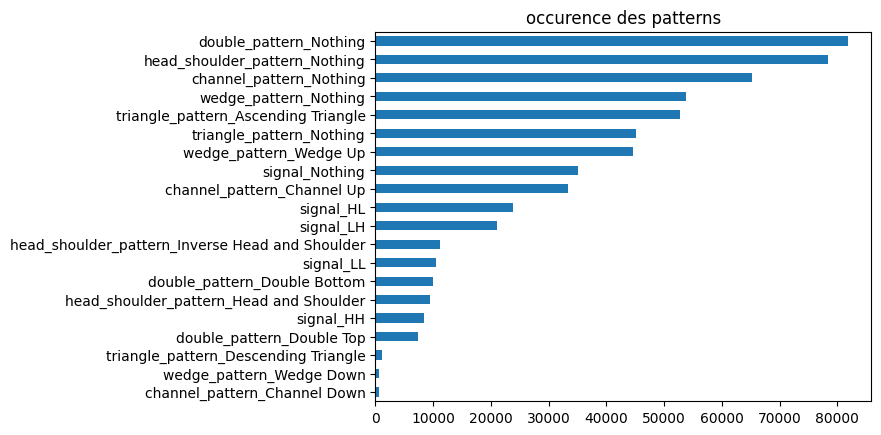

In [8]:
pd.get_dummies(data[technical_var].select_dtypes(include='object')).replace({True:1,False:0}).sum().sort_values().plot(kind='barh')
plt.title('occurence des patterns')
plt.show()

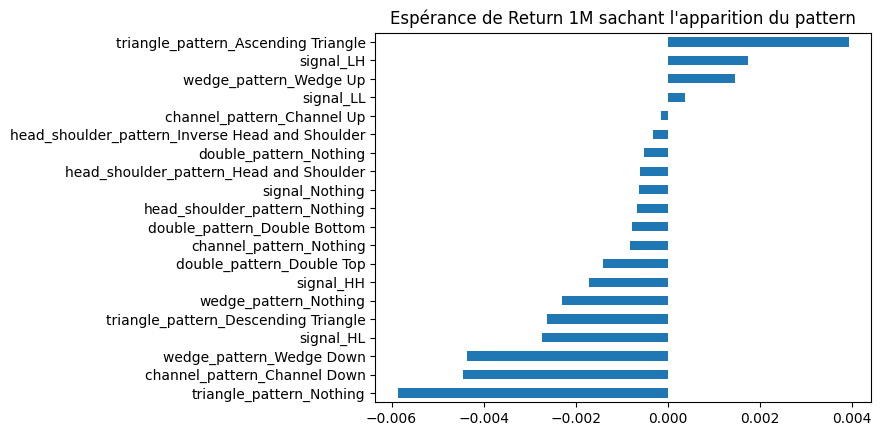

In [9]:
pd.get_dummies(data[technical_var].select_dtypes(include='object')).replace({True:1,False:0}).apply(lambda x:sum(x*data[label].values)/sum(x)).sort_values(ascending=True).plot(kind='barh')
plt.title("Espérance de Return 1M sachant l'apparition du pattern")
plt.show()

In [10]:
pd.get_dummies(data[technical_var].select_dtypes(include='object'),dtype=int).apply(lambda x:scipy.stats.spearmanr(x,data[label].values))#.sort_values(ascending=True).plot(kind='barh')

,wedge_pattern_Nothing,wedge_pattern_Wedge Down,wedge_pattern_Wedge Up,head_shoulder_pattern_Head and Shoulder,head_shoulder_pattern_Inverse Head and Shoulder,head_shoulder_pattern_Nothing,triangle_pattern_Ascending Triangle,triangle_pattern_Descending Triangle,triangle_pattern_Nothing,double_pattern_Double Bottom,double_pattern_Double Top,double_pattern_Nothing,signal_HH,signal_HL,signal_LH,signal_LL,signal_Nothing,channel_pattern_Channel Down,channel_pattern_Channel Up,channel_pattern_Nothing
0,-2.809812e-02,-0.006093,2.915929e-02,0.003996,-0.003278,-0.000341,7.758184e-02,-0.006655,-7.630847e-02,0.000382,-0.002296,0.001281,-0.00884,-2.090580e-02,2.152560e-02,0.003673,0.003069,-0.004642,0.010533,-0.009736
1,9.182091e-19,0.055162,4.358625e-20,0.208528,0.302314,0.914415,4.673146e-132,0.036216,8.250469e-128,0.904293,0.470010,0.686803,0.00540,4.701756e-11,1.242240e-11,0.247656,0.334093,0.144035,0.000917,0.002182


In [6]:
# preprocessing
boolmask=(data.reset_index()['Date']<end_date)&(data.reset_index()['Date']>=start_date)
Y=data.loc[boolmask.values, label]
X=data.loc[boolmask.values,fondamental_var+technical_var]
numerical_features=list(X.select_dtypes(exclude='object').columns)
categorical_features=list(X.select_dtypes(include='object').columns)


numerical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', MinMaxScaler())])

categorical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('scaler',  OneHotEncoder(handle_unknown='ignore', drop='first',
            sparse_output=False,
            dtype=int),)])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_pipeline, numerical_features),
        ('cat', categorical_pipeline, categorical_features),
    ])

X_train,X_test=X.loc[X.index.get_level_values(1)<split_date],X.loc[X.index.get_level_values(1)>=split_date+pd.DateOffset(months=3)]
y_train,y_test=Y.loc[X_train.index].values,Y.loc[X_test.index].values

In [7]:
X_train=preprocessor.fit_transform(X_train.reset_index().drop(['Date','Company SEDOL'],axis=1))
X_test=preprocessor.transform(X_test.reset_index().drop(['Date','Company SEDOL'],axis=1))

# reshape y
y_train=y_train.reshape(-1,1)
y_test=y_test.reshape(-1,1)

In [8]:
def hyperparameters_tuning(X,Y,model_name,n_trial):
    def objective(trial):
        if model_name=='Random Forest':
            parameters={'max_depth': trial.suggest_int('max_depth',3,7),
                        'max_features': trial.suggest_float('max_features', 0.1,1),
                        'criterion': trial.suggest_categorical('criterion',['gini','entropy']),
                        'min_samples_split': trial.suggest_float('min_samples_split', 0.001,0.01),
                        'class_weight':'balanced',
                        'n_jobs':-1,
                        'n_estimators': 200
                        }
            model=RandomForestClassifier(**parameters)
        elif model_name=='XGBOOST':
            parameters={'max_depth': trial.suggest_int('max_depth',3,7),
                        'max_features': trial.suggest_float('max_features', 0.2,1),
                        'criterion': trial.suggest_categorical('criterion',['gini','entropy']),
                        'learning_rate':trial.suggest_float('learning_rate',0.01,0.3),
                        'reg_alpha': trial.suggest_float('reg_alpha',0.1,10),
                        'reg_lambda': trial.suggest_float('reg_lambda',0.1,10),
                        'max_iterations': trial.suggest_int('max_iterations',20,100),
                        'n_estimators': trial.suggest_int('n_estimators',5,10),
                        'colsample_bytree': trial.suggest_float('colsample_bytree',0.2,1),
                        'objective': 'binary:logistic',
                        }
            model=XGBClassifier(**parameters)
        return cross_val_score(model, X, Y, n_jobs=-1, cv=5,scoring='f1').mean()
        
    study=optuna.create_study(direction='maximize')
    study.optimize(objective,n_trials=n_trial)
    print(study.best_params)
    return study.best_params


In [9]:
params_rf=hyperparameters_tuning(X_train,(y_train>0).astype(int),'Random Forest',50)

[I 2025-10-01 09:54:41,554] A new study created in memory with name: no-name-b4e62aa9-f888-460c-a0ae-0a3f4a2f4e85
[I 2025-10-01 09:55:23,734] Trial 0 finished with value: 0.5349422661492202 and parameters: {'max_depth': 7, 'max_features': 0.48382147090153793, 'criterion': 'entropy', 'min_samples_split': 0.002196647292788521}. Best is trial 0 with value: 0.5349422661492202.
[I 2025-10-01 09:55:33,580] Trial 1 finished with value: 0.5268680732961031 and parameters: {'max_depth': 4, 'max_features': 0.1289182956099903, 'criterion': 'gini', 'min_samples_split': 0.007333537864650781}. Best is trial 0 with value: 0.5349422661492202.
[I 2025-10-01 09:55:55,882] Trial 2 finished with value: 0.5310398644647201 and parameters: {'max_depth': 5, 'max_features': 0.7152142286513603, 'criterion': 'gini', 'min_samples_split': 0.004655025465499009}. Best is trial 0 with value: 0.5349422661492202.
[I 2025-10-01 09:56:22,443] Trial 3 finished with value: 0.533362809810222 and parameters: {'max_depth': 7, 

{'max_depth': 7, 'max_features': 0.5676244209869687, 'criterion': 'gini', 'min_samples_split': 0.002243478399775018}


In [10]:
rf=RandomForestClassifier(**params_rf,n_estimators=200,class_weight='balanced',n_jobs=-1)
rf.fit(X_train,(y_train>0).astype(int))
feature_name=list(preprocessor.transformers_[1][1]['scaler'].get_feature_names_out(categorical_features))+list(numerical_features)
pd.DataFrame(rf.feature_importances_,index=feature_name,columns=['importances']).sort_values(by='importances',ascending=False)

c:\Users\GONONDYA\AppData\Local\anaconda3\envs\Y1\Lib\site-packages\sklearn\base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


,importances
fwma,0.085158
double_pattern_Double Top,0.047636
ema,0.045207
signal_LL,0.043325
BullishEngulfing,0.038308
...,...
Value Avg Percentile_change_12M,0.000283
Value Avg Percentile_change_1M,0.000279
Quality Avg Percentile_change_6M,0.000243
Quality Avg Percentile_change_12M,0.000212


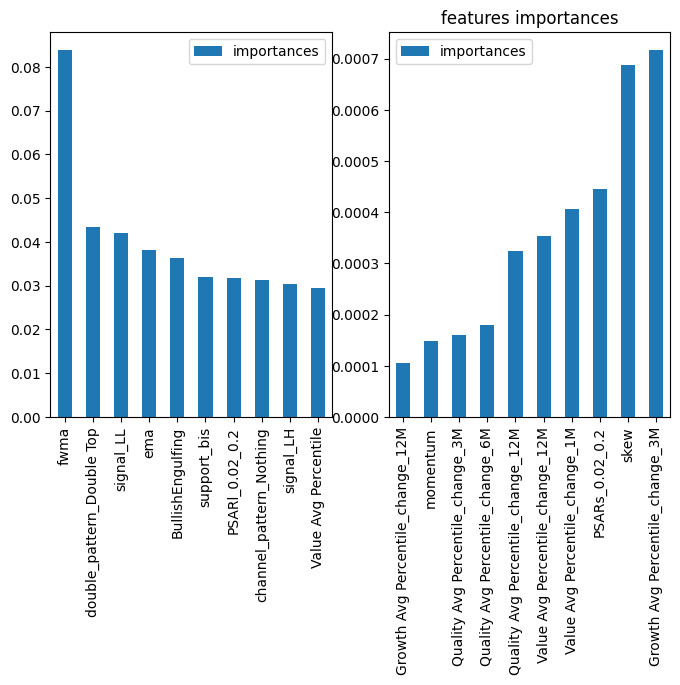

In [37]:
fig,ax=plt.subplots(1,2,figsize=(8,5))
pd.DataFrame(rf.feature_importances_,index=feature_name,columns=['importances']).sort_values(by='importances',ascending=False)[:10].plot(kind='bar',ax=ax[0])
pd.DataFrame(rf.feature_importances_,index=feature_name,columns=['importances']).sort_values(by='importances',ascending=True)[:10].plot(kind='bar',ax=ax[1])
plt.title('features importances')
plt.show()

In [11]:
pred=rf.predict(X_test)
accuracy=accuracy_score((y_test>0).astype(int),pred)
f1=f1_score((y_test>0).astype(int),pred)
auc=roc_auc_score((y_test>0).astype(int),pred)
print(" f1_score: {}, accuracy: {}, auc:{} ".format(accuracy,f1,auc))
confusion_matrix((y_test>0).astype(int),pred)

 f1_score: 0.5367090232319343, accuracy: 0.5628822282773236, auc:0.5368025212449313 


array([[3715, 4088],
       [3131, 4648]], dtype=int64)

In [20]:
import Backtest_training_frequency 
model=RandomForestClassifier(**params_rf,n_estimators=200,n_jobs=-1,class_weight='balanced')
features=numerical_features+categorical_features
bench,ptf,screen=Backtest_training_frequency.Backtest_yearly(model,screen_agg,returns,data,'2015-01-01',secto_us,liste_noire,features,"information_ratio 1.0M",
                                                             ponderation="Racine cube",percentile=0.2,bench='MSCI US',ptf_name='ML US Q1')

100%|██████████| 11/11 [04:47<00:00, 26.16s/it]


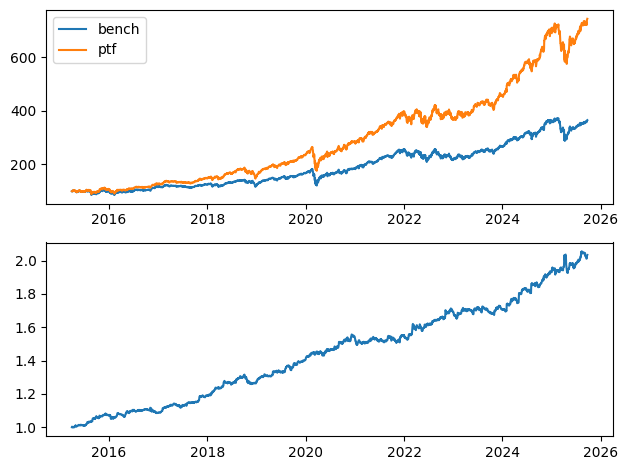

In [40]:
fig,ax=plt.subplots(2)
ax[0].plot(bench,label='bench')
ax[0].plot(ptf,label='ptf')
ax[1].plot(ptf/bench)
ax[0].legend()
plt.tight_layout()
plt.show()

In [42]:
rf=ptf.reset_index()
rf['year']=rf['Date'].apply(lambda x:x.year)
rf=rf.groupby(by='year').agg('first')
U=np.nanmean(rf['Contrib'].pct_change()-0.02)
std=np.nanstd(rf['Contrib'].pct_change())
U/std

1.1367542151552015

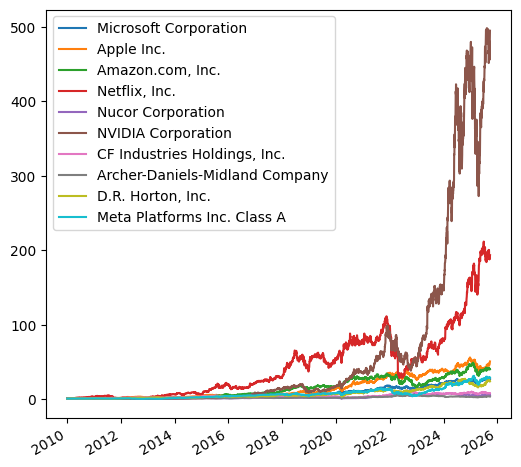

In [22]:
names={}
for isin in screen['ISIN'].value_counts()[:10].index:
    name=df[df['ISIN']==isin]['Name'].iloc[0]
    names[isin]=name
sedol={}
for isin in names:
    sedol[isin]=df[df['ISIN']==isin].index.get_level_values(0)[0]
top_ptf=(1+returns[returns.index.get_level_values(0)>'2010-01-01'][sedol.values()]).cumprod()
top_ptf.columns=names.values()
top_ptf.plot(kind='line',figsize=(6,6))
plt.show()

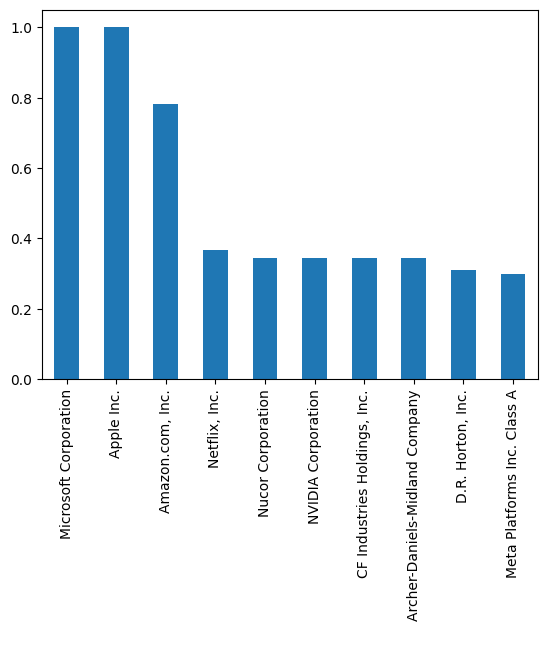

In [23]:
(screen['ISIN'].value_counts().sort_values(ascending=False)/len(screen['Date'].unique()))[:10].plot(kind='bar',xlabel=' ')
plt.gca().set_xticklabels(names.values())
plt.show()

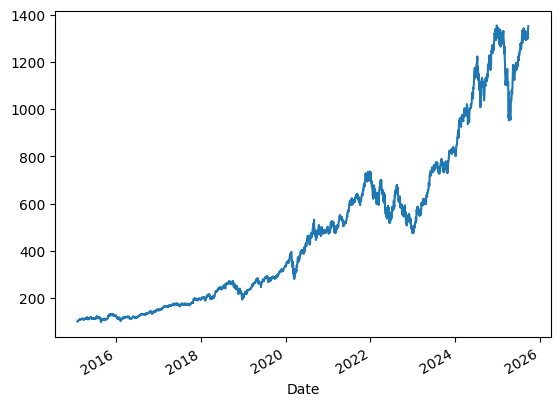

In [24]:
myfunc=generation_sec_list(screen_agg[screen_agg['Company SEDOL'].isin(sedol.values())],returns, "MSCI US", 1, '2015-01-01', 'Score ML', 'ML US Q1', reco_secto=secto_us,
                            ponderation='Market cap',esg_exclusion=0, cut_mkt_cap=0, 
                            score_neutral="ICB 19",weight_neutral="ICB 19",
                            top_mandatory = 0,liste_noire=liste_noire,
                            top_mandatory_with_bench_weight = False)
perf_bench=myfunc.get_bench_perf(screen_agg)
perf_bench.plot(kind='line')
plt.show()

In [25]:
rf=perf_bench.reset_index()
rf['year']=rf['Date'].apply(lambda x:x.year)
rf=rf.groupby(by='year').agg('first')
U=np.nanmean(rf['Contrib'].pct_change()-0.02)
std=np.nanstd(rf['Contrib'].pct_change())
U/std

1.0766686698220616

In [26]:
params_xg=hyperparameters_tuning(X_train,(y_train>0).astype(int),'XGBOOST',10)

[I 2025-09-23 17:27:01,758] A new study created in memory with name: no-name-eb926048-4b8b-4358-b618-997db9e71d2d
[I 2025-09-23 17:27:02,955] Trial 0 finished with value: 0.5293186273183904 and parameters: {'max_depth': 7, 'max_features': 0.9147996719631891, 'criterion': 'gini', 'learning_rate': 0.05656417684998562, 'reg_alpha': 5.133596851791382, 'reg_lambda': 2.4051891828374212, 'max_iterations': 80, 'n_estimators': 10, 'colsample_bytree': 0.9824077539166147}. Best is trial 0 with value: 0.5293186273183904.
[I 2025-09-23 17:27:03,720] Trial 1 finished with value: 0.5352067723714317 and parameters: {'max_depth': 3, 'max_features': 0.20518386836999525, 'criterion': 'gini', 'learning_rate': 0.09956644180216588, 'reg_alpha': 4.877575611565888, 'reg_lambda': 4.230368437843534, 'max_iterations': 51, 'n_estimators': 5, 'colsample_bytree': 0.992728510880247}. Best is trial 1 with value: 0.5352067723714317.
[I 2025-09-23 17:27:04,406] Trial 2 finished with value: 0.5329303175215946 and parame

{'max_depth': 3, 'max_features': 0.25541148271532566, 'criterion': 'entropy', 'learning_rate': 0.01769679327032484, 'reg_alpha': 8.933380640930844, 'reg_lambda': 9.419407292309058, 'max_iterations': 32, 'n_estimators': 6, 'colsample_bytree': 0.296284120706352}


In [ ]:
xg=XGBClassifier(**params_xg, objective='binary:logistic')
xg.fit(X_train,(y_train>0).astype(int))
feature_name=list(preprocessor.transformers_[1][1]['scaler'].get_feature_names_out(categorical_features))+list(numerical_features)
pd.DataFrame(xg.feature_importances_,index=feature_name,columns=['importances']).sort_values(by='importances',ascending=False)

,importances
PSARl_0.02_0.2,0.110706
atr,0.038520
PiercingPattern,0.036441
LowVol Avg Percentile,0.033636
BBB_5_2.0,0.032951
...,...
rsi,0.000000
MorningStar,0.000000
Value Avg Percentile_change_3M,0.000000
Value Avg Percentile_change_1M,0.000000


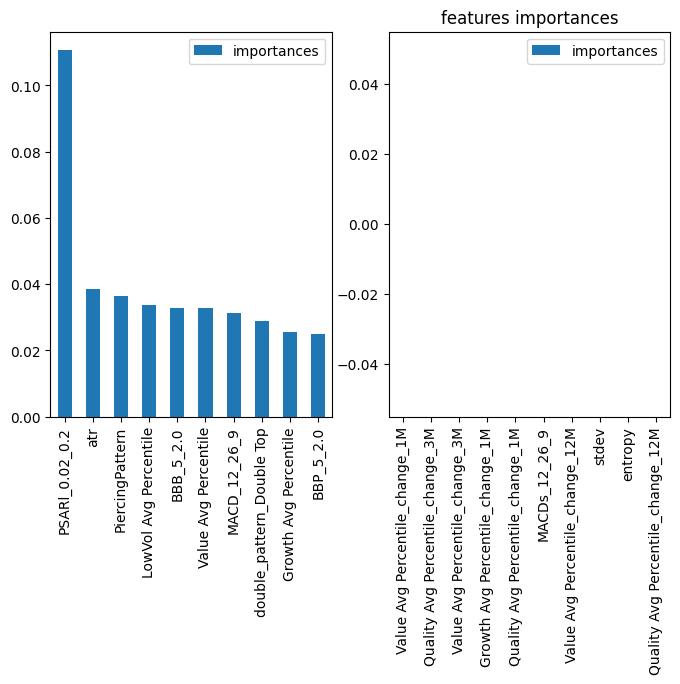

In [ ]:
fig,ax=plt.subplots(1,2,figsize=(8,5))
pd.DataFrame(xg.feature_importances_,index=feature_name,columns=['importances']).sort_values(by='importances',ascending=False)[:10].plot(kind='bar',ax=ax[0])
pd.DataFrame(xg.feature_importances_,index=feature_name,columns=['importances']).sort_values(by='importances',ascending=True)[:10].plot(kind='bar',ax=ax[1])
plt.title('features importances')
plt.show()

In [ ]:
pred=xg.predict(X_test)
accuracy=accuracy_score((y_test>0).astype(int),pred)
f1=f1_score((y_test>0).astype(int),pred)
auc=roc_auc_score((y_test>0).astype(int),pred)
print(" f1_score: {}, accuracy: {}, auc:{} ".format(accuracy,f1,auc))
confusion_matrix((y_test>0).astype(int),pred)

 f1_score: 0.5399820305480683, accuracy: 0.5727229375298045, auc:0.540101335534075 


array([[3610, 4193],
       [2975, 4804]], dtype=int64)

100%|██████████| 11/11 [02:12<00:00, 12.04s/it]


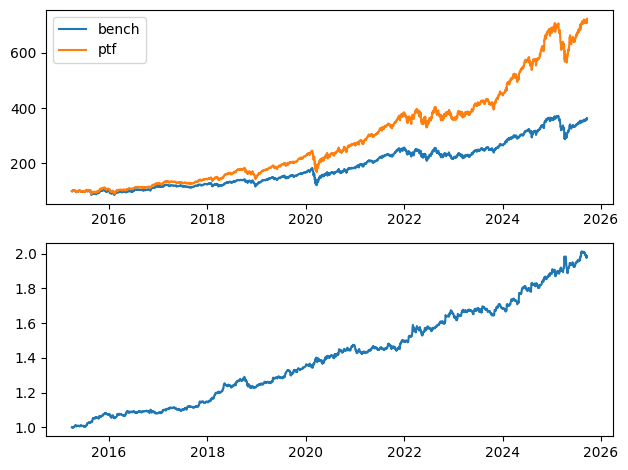

In [ ]:
import Backtest_training_frequency 
model=RandomForestClassifier(**params_rf,n_estimators=100,n_jobs=-1)
features=numerical_features+categorical_features
bench,ptf,screen=Backtest_training_frequency.Backtest_yearly(model,screen_agg,returns,data,'2015-01-01',secto_us,liste_noire,features,"information_ratio 1.0M",
                                                             bench='MSCI US',ptf_name='ML US Q1')
fig,ax=plt.subplots(2)
ax[0].plot(bench,label='bench')
ax[0].plot(ptf,label='ptf')
ax[1].plot(ptf/bench)
ax[0].legend()
plt.tight_layout()
plt.show()

## Variables fondamentales uniquement

In [29]:
X=data.loc[boolmask.values,fondamental_var]

numerical_features=list(X.select_dtypes(exclude='object').columns)
categorical_features=list(X.select_dtypes(include='object').columns)

numerical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', MinMaxScaler())])


categorical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('scaler',  OneHotEncoder(handle_unknown='ignore', drop='first',
            sparse_output=False,
            dtype=int))])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_pipeline, numerical_features),
        ('cat', categorical_pipeline, categorical_features),
    ])

X_train,X_test=X.loc[X.index.get_level_values(1)<split_date],X.loc[X.index.get_level_values(1)>=split_date+pd.DateOffset(months=3)]

X_train=preprocessor.fit_transform(X_train.reset_index().drop(['Date','Company SEDOL'],axis=1))
X_test=preprocessor.transform(X_test.reset_index().drop(['Date','Company SEDOL'],axis=1))

In [30]:
params_rf=hyperparameters_tuning(X_train,(y_train>0).astype(int),'Random Forest',50)

[I 2025-10-01 11:07:30,127] A new study created in memory with name: no-name-aaa1f639-31b3-4c41-b90c-4376aa6dd57c
[I 2025-10-01 11:07:50,191] Trial 0 finished with value: 0.541377397030023 and parameters: {'max_depth': 5, 'max_features': 0.5218168244908686, 'criterion': 'entropy', 'min_samples_split': 0.005418432269771294}. Best is trial 0 with value: 0.541377397030023.
[I 2025-10-01 11:07:59,572] Trial 1 finished with value: 0.541757281265266 and parameters: {'max_depth': 7, 'max_features': 0.1386077093425756, 'criterion': 'entropy', 'min_samples_split': 0.007823758692326606}. Best is trial 1 with value: 0.541757281265266.
[I 2025-10-01 11:08:07,508] Trial 2 finished with value: 0.5566729283338705 and parameters: {'max_depth': 3, 'max_features': 0.25307409853165663, 'criterion': 'gini', 'min_samples_split': 0.007754997075252921}. Best is trial 2 with value: 0.5566729283338705.
[I 2025-10-01 11:08:13,355] Trial 3 finished with value: 0.5325473383124336 and parameters: {'max_depth': 6, 

{'max_depth': 3, 'max_features': 0.23924524504272068, 'criterion': 'entropy', 'min_samples_split': 0.006898071506073142}


In [31]:
rf=RandomForestClassifier(**params_rf,n_estimators=100,n_jobs=-1)
# rf=XGBClassifier(max_depth=5,objective='binary:logistic',
#                   n_estimators=70,max_features=30,learning_rate=0.1,random_state=42)
rf.fit(X_train,(y_train>0).astype(int))
feature_name=list(numerical_features)
pd.DataFrame(rf.feature_importances_,index=feature_name,columns=['importances']).sort_values(by='importances',ascending=False)

,importances
Quality Avg Percentile_change_3M,0.155374
Quality Avg Percentile_change_6M,0.092427
Value Avg Percentile_change_1M,0.090880
Value Avg Percentile_change_3M,0.084420
Quality Avg Percentile_change_1M,0.071081
Value Avg Percentile,0.057245
Growth Avg Percentile_change_6M,0.053491
Quality Avg Percentile_change_12M,0.050240
Value Avg Percentile_change_12M,0.048155
Value Avg Percentile_change_6M,0.047063


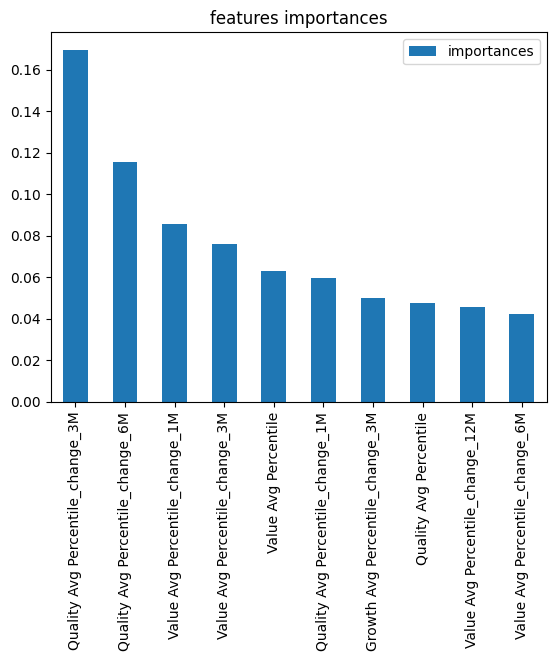

In [ ]:
pd.DataFrame(rf.feature_importances_,index=feature_name,columns=['importances']).sort_values(by='importances',ascending=False)[:10].plot(kind='bar')
plt.title('features importances')
plt.show()

In [ ]:
pred=rf.predict(X_test)
accuracy=accuracy_score((y_test>0).astype(int),pred)
f1=f1_score((y_test>0).astype(int),pred)
auc=roc_auc_score((y_test>0).astype(int),pred)
print(" f1_score: {}, accuracy: {}, auc:{} ".format(accuracy,f1,auc))
confusion_matrix((y_test>0).astype(int),pred)

 f1_score: 0.5184828648440508, accuracy: 0.5478758662247665, auc:0.5185842274217017 


array([[3533, 4270],
       [3233, 4546]], dtype=int64)

In [32]:
import Backtest_training_frequency 
model=RandomForestClassifier(**params_rf,n_estimators=100,n_jobs=-1)
features=numerical_features+categorical_features
bench,ptf,screen=Backtest_training_frequency.Backtest_yearly(model,screen_agg,returns,data,'2015-01-01',secto_us,liste_noire,features,'information_ratio 1.0M',bench='MSCI US',ptf_name='ML US Q1')

100%|██████████| 11/11 [00:38<00:00,  3.50s/it]


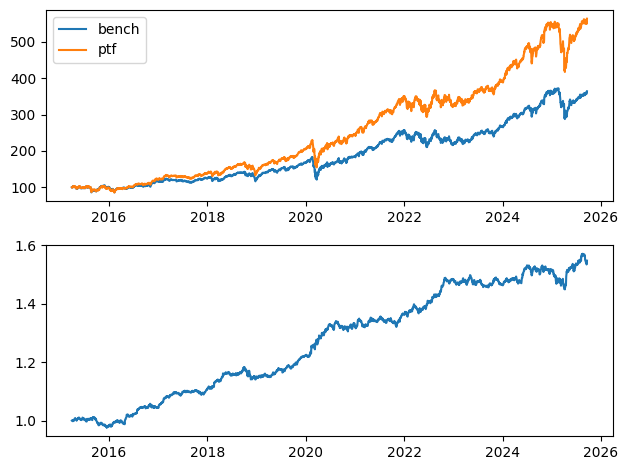

In [ ]:
fig,ax=plt.subplots(2)
ax[0].plot(bench,label='bench')
ax[0].plot(ptf,label='ptf')
ax[1].plot(ptf/bench)
ax[0].legend()
plt.tight_layout()
plt.show()

### use only patterns 

In [ ]:
X=data.loc[boolmask.values,technical_var]

numerical_features=list(X.select_dtypes(exclude='object').columns)
categorical_features=list(X.select_dtypes(include='object').columns)

numerical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', MinMaxScaler())])


categorical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('scaler',  OneHotEncoder(handle_unknown='ignore', drop='first',
            sparse_output=False,
            dtype=int))])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_pipeline, numerical_features),
        ('cat', categorical_pipeline, categorical_features),
    ])

X_train,X_test=X.loc[X.index.get_level_values(1)<split_date],X.loc[X.index.get_level_values(1)>=split_date+pd.DateOffset(months=3)]
y_train,y_test=Y.loc[X_train.index].values,Y.loc[X_test.index].values

X_train=preprocessor.fit_transform(X_train.reset_index().drop(['Date','Company SEDOL'],axis=1))
X_test=preprocessor.transform(X_test.reset_index().drop(['Date','Company SEDOL'],axis=1))

In [ ]:
params_rf=hyperparameters_tuning(X_train,(y_train>0).astype(int),'Random Forest',10)

[I 2025-09-22 15:02:01,821] A new study created in memory with name: no-name-73ea2672-d8bf-4fef-b822-caf709709b7c
[I 2025-09-22 15:02:20,443] Trial 0 finished with value: 0.5382879166115282 and parameters: {'max_depth': 4, 'max_features': 0.28760405706325665, 'criterion': 'gini', 'min_samples_split': 0.007059960399839681}. Best is trial 0 with value: 0.5382879166115282.
[I 2025-09-22 15:03:29,843] Trial 1 finished with value: 0.5386351817785594 and parameters: {'max_depth': 3, 'max_features': 0.7283553943871635, 'criterion': 'gini', 'min_samples_split': 0.00838024010088467}. Best is trial 1 with value: 0.5386351817785594.
[I 2025-09-22 15:03:43,535] Trial 2 finished with value: 0.5426963664601393 and parameters: {'max_depth': 7, 'max_features': 0.445938100084319, 'criterion': 'entropy', 'min_samples_split': 0.007184424325578187}. Best is trial 2 with value: 0.5426963664601393.
[I 2025-09-22 15:03:49,691] Trial 3 finished with value: 0.5359713319156476 and parameters: {'max_depth': 4, '

{'max_depth': 6, 'max_features': 0.5403750585711579, 'criterion': 'gini', 'min_samples_split': 0.006793526027482012}


In [ ]:
rf=RandomForestClassifier(**params_rf,n_estimators=100,n_jobs=-1)
# rf=XGBClassifier(max_depth=5,objective='binary:logistic',
#                   n_estimators=70,max_features=30,learning_rate=0.1,random_state=42)
rf.fit(X_train,(y_train>0).astype(int))
feature_name=list(preprocessor.transformers_[1][1].get_feature_names_out(categorical_features)) + list(numerical_features)
pd.DataFrame(rf.feature_importances_,index=feature_name,columns=['importances']).sort_values(by='importances',ascending=False)

,importances
MACD_12_26_9,0.151444
momentum,0.079421
BullishEngulfing,0.065591
support_bis,0.061435
PSARl_0.02_0.2,0.054383
BullishHarami,0.053218
Doji,0.049648
wedge_pattern_Wedge Up,0.049448
wedge_pattern_Wedge Down,0.048801
DarkCloudCover,0.045629


In [ ]:
pred=rf.predict(X_test)
accuracy=accuracy_score((y_test>0).astype(int),pred)
f1=f1_score((y_test>0).astype(int),pred)
auc=roc_auc_score((y_test>0).astype(int),pred)
print(" f1_score: {}, accuracy: {}, auc:{} ".format(accuracy,f1,auc))
confusion_matrix((y_test>0).astype(int),pred)

 f1_score: 0.5313823642664613, accuracy: 0.5479197622585439, auc:0.5314399679852583 


array([[3855, 3948],
       [3354, 4425]], dtype=int64)

In [ ]:
model=RandomForestClassifier(max_depth=5,max_features=30,n_estimators=200,criterion='entropy',random_state=42)
features=numerical_features+categorical_features
bench,ptf,screen=Backtest_training_frequency.Backtest_yearly(model,screen_agg,returns,data,'2015-01-01',secto_us,liste_noire,features,label,bench='MSCI US',ptf_name='ML US Q1')

100%|██████████| 11/11 [05:38<00:00, 30.74s/it]


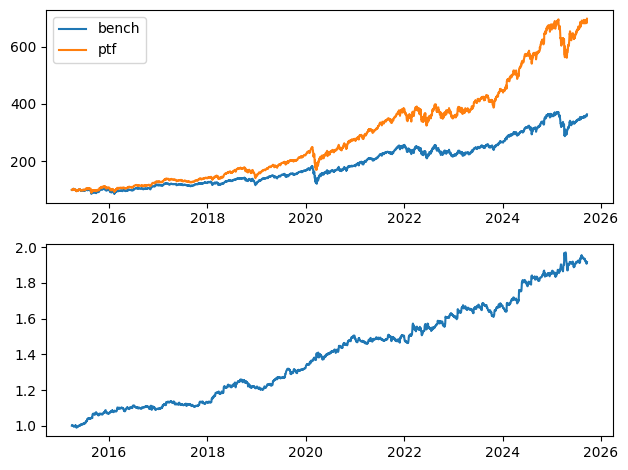

In [ ]:
fig,ax=plt.subplots(2)
ax[0].plot(bench,label='bench')
ax[0].plot(ptf,label='ptf')
ax[1].plot(ptf/bench)
ax[0].legend()
plt.tight_layout()
plt.show()